# Edge Detection Segmentation
What divides two objects in an image? There is always an edge between two adjacent regions with different grayscale values (pixel values). The edges can be considered as the discontinuous local features of an image.

We can make use of this discontinuity to detect edges and hence define a boundary of the object. This helps us in detecting the shapes of multiple objects present in a given image. Now the question is how can we detect these edges? This is where we can make use of filters and convolutions. Refer to this article if you need to learn about these concepts.

Here’s the step-by-step process of how this works:

1. Take the weight matrix


2. Put it on top of the image


3. Perform element-wise multiplication and get the output


4. Move the weight matrix as per the stride chosen


5. Convolve until all the pixels of the input are used


The values of the weight matrix define the output of the convolution. My advice – it helps to extract features from the input. Researchers have found that choosing some specific values for these weight matrices helps us to detect horizontal or vertical edges (or even the combination of horizontal and vertical edges).

One such weight matrix is the sobel operator. It is typically used to detect edges. The sobel operator has two weight matrices – one for detecting horizontal edges and the other for detecting vertical edges. Let me show how these operators look and we will then implement them in Python.

Sobel filter (horizontal) =

1	2	1
0	0	0
-1	-2	-1
 

Sobel filter (vertical) =

-1	0	1
-2	0	2
-1	0	1
 

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from skimage.color import rgb2gray
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import ndimage

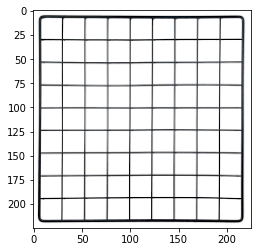

In [3]:
image = plt.imread('/content/drive/MyDrive/KLA/index.png')
plt.imshow(image)

It should be fairly simple for us to understand how the edges are detected in this image. Let’s convert it into grayscale and define the sobel filter (both horizontal and vertical) that will be convolved over this image:

In [5]:
# converting to grayscale
gray = rgb2gray(image)

# defining the sobel filters
sobel_horizontal = np.array([np.array([1, 2, 1]), np.array([0, 0, 0]), np.array([-1, -2, -1])])
print(sobel_horizontal, 'is a kernel for detecting horizontal edges')
 
sobel_vertical = np.array([np.array([-1, 0, 1]), np.array([-2, 0, 2]), np.array([-1, 0, 1])])
print(sobel_vertical, 'is a kernel for detecting vertical edges')

[[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]] is a kernel for detecting horizontal edges
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]] is a kernel for detecting vertical edges


Now, convolve this filter over the image using the convolve function of the ndimage package from scipy.

In [6]:
out_h = ndimage.convolve(gray, sobel_horizontal, mode='reflect')
out_v = ndimage.convolve(gray, sobel_vertical, mode='reflect')
# here mode determines how the input array is extended when the filter overlaps a border.

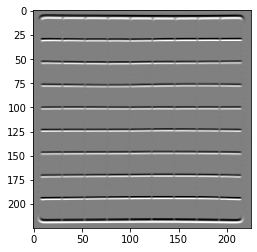

In [7]:
plt.imshow(out_h, cmap='gray')

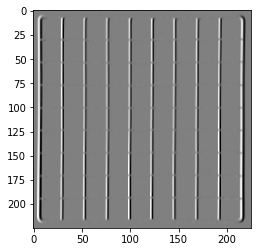

In [8]:
plt.imshow(out_v, cmap='gray')

Here, we are able to identify the horizontal as well as the vertical edges. There is one more type of filter that can detect both horizontal and vertical edges at the same time. This is called the laplace operator:

1	1	1

1	-8	1

1	1	1

Let’s define this filter in Python and convolve it on the same image:

In [9]:

kernel_laplace = np.array([np.array([1, 1, 1]), np.array([1, -8, 1]), np.array([1, 1, 1])])
print(kernel_laplace, 'is a laplacian kernel')

[[ 1  1  1]
 [ 1 -8  1]
 [ 1  1  1]] is a laplacian kernel


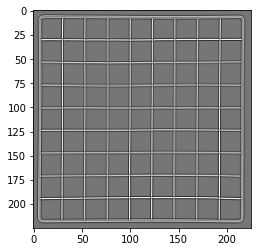

In [10]:
out_l = ndimage.convolve(gray, kernel_laplace, mode='reflect')
plt.imshow(out_l, cmap='gray')

Here, we can see that our method has detected both horizontal as well as vertical edges. I encourage you to try it on different images and share your results with me. Remember, the best way to learn is by practicing!

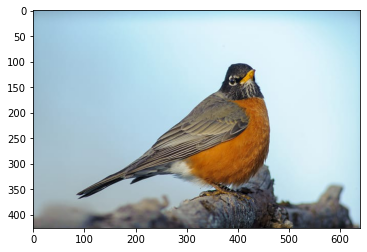

In [11]:
image = plt.imread('/content/drive/MyDrive/bird.jpg')
plt.imshow(image)

In [12]:
# converting to grayscale
gray = rgb2gray(image)

In [13]:
out_h = ndimage.convolve(gray, sobel_horizontal, mode='reflect')
out_v = ndimage.convolve(gray, sobel_vertical, mode='reflect')
# here mode determines how the input array is extended when the filter overlaps a border.

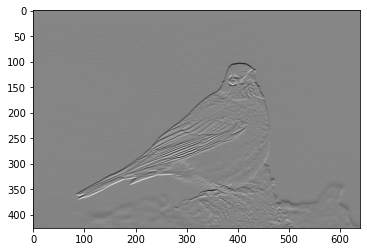

In [14]:
plt.imshow(out_h, cmap='gray')

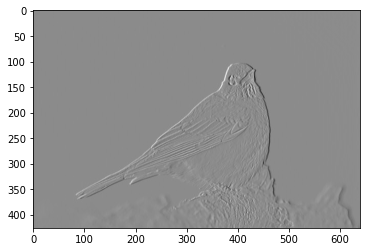

In [15]:
plt.imshow(out_v, cmap='gray')

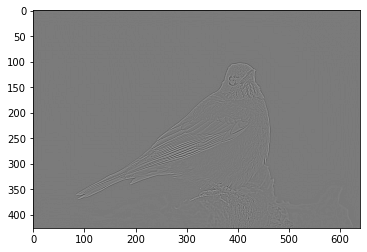

In [16]:
out_l = ndimage.convolve(gray, kernel_laplace, mode='reflect')
plt.imshow(out_l, cmap='gray')